# Chapter 16 — Covariance

## Learning Objectives

By the end of this chapter, you will be able to:

- Explain why covariance is used to describe how two quantitative variables move together
- Calculate sample covariance from centered deviations
- Interpret positive, negative, and near-zero covariance
- Compute covariance with pandas and NumPy
- Read a covariance matrix
- Explain why the magnitude of covariance depends on measurement units
- Recognize why covariance alone does not imply causation
- Connect covariance to the next chapter: correlation analysis


## 1. From One Variable to Two Variables

Earlier chapters focused mainly on describing or comparing variables.

Now we ask a different question:

> **When one quantitative variable changes, does another variable tend to change with it?**

Examples include:

- study time and exam score
- temperature and energy consumption
- advertising expenditure and sales

A scatter plot is often the first useful tool for examining such a relationship.

In this chapter, we focus on **covariance**, a numerical measure of how two quantitative variables vary together.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root containing a data/ directory.")

ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / "data" / "16_covariance.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,student_id,study_hours_per_week,exam_score,leisure_hours_per_day
0,S001,8.2,82.2,4.2
1,S002,3.8,59.9,4.1
2,S003,10.9,92.2,3.7
3,S004,1.8,56.0,7.8
4,S005,1.8,57.8,8.0


## 2. Dataset

The dataset contains **60 fictional students**.

| Variable | Description |
|---|---|
| `student_id` | Fictional student identifier |
| `study_hours_per_week` | Weekly study hours |
| `exam_score` | Assessment score |
| `leisure_hours_per_day` | Daily leisure hours |

The data are synthetic and are designed only for statistical learning.


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             60 non-null     object 
 1   study_hours_per_week   60 non-null     float64
 2   exam_score             60 non-null     float64
 3   leisure_hours_per_day  60 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.0+ KB


In [3]:
df.describe()


,study_hours_per_week,exam_score,leisure_hours_per_day
count,60.000000,60.000000,60.000000
mean,7.103333,73.246667,4.758333
std,3.023746,11.227863,1.700677
min,1.700000,47.300000,1.600000
25%,4.300000,66.725000,3.700000
50%,7.250000,73.200000,4.600000
75%,9.625000,82.050000,5.675000
max,12.000000,96.500000,8.000000


## 3. Start with a Scatter Plot

Before calculating a statistic, visualize the two variables.

For `study_hours_per_week` and `exam_score`, each point represents one student.


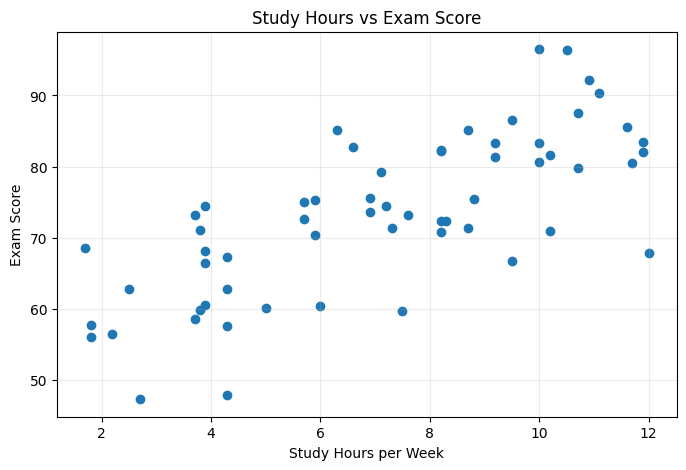

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours_per_week"], df["exam_score"])
plt.xlabel("Study Hours per Week")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.grid(alpha=0.25)
plt.show()


The scatter plot suggests that students with more study hours tend to have higher exam scores.

Covariance gives us a numerical way to describe the **direction of this joint variation**.


## 4. Sample Covariance

For two variables \(X\) and \(Y\), the sample covariance is

$$
s_{XY}
=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{n-1}
$$

where:

- \(x_i\) and \(y_i\) are individual observations
- \(\bar{x}\) and \(\bar{y}\) are sample means
- \(n\) is the sample size

The key idea is the product

$$
(x_i-\bar{x})(y_i-\bar{y})
$$

for each observation.

### Why multiply the deviations?

Consider whether each observation is above or below its variable's mean.

| X deviation | Y deviation | Product |
|---|---|---|
| Positive | Positive | Positive |
| Negative | Negative | Positive |
| Positive | Negative | Negative |
| Negative | Positive | Negative |

If the two variables often move in the **same direction**, the products tend to be positive.

If they often move in **opposite directions**, the products tend to be negative.


## 5. Calculate Covariance Step by Step

Let's calculate the covariance between study hours and exam score manually.


In [5]:
x = df["study_hours_per_week"]
y = df["exam_score"]

x_mean = x.mean()
y_mean = y.mean()

x_mean, y_mean


(np.float64(7.1033333333333335), np.float64(73.24666666666667))

In [6]:
cov_work = pd.DataFrame({
    "study_hours": x,
    "exam_score": y,
    "x_deviation": x - x_mean,
    "y_deviation": y - y_mean
})

cov_work["deviation_product"] = (
    cov_work["x_deviation"] * cov_work["y_deviation"]
)

cov_work.head(10)


,study_hours,exam_score,x_deviation,y_deviation,deviation_product
0,8.2,82.2,1.096667,8.953333,9.818822
1,3.8,59.9,-3.303333,-13.346667,44.088489
2,10.9,92.2,3.796667,18.953333,71.959489
3,1.8,56.0,-5.303333,-17.246667,91.464822
4,1.8,57.8,-5.303333,-15.446667,81.918822
5,7.2,74.5,0.096667,1.253333,0.121156
6,10.0,96.5,2.896667,23.253333,67.357156
7,8.8,75.4,1.696667,2.153333,3.653489
8,11.6,85.6,4.496667,12.353333,55.548822
9,2.5,62.8,-4.603333,-10.446667,48.089489


In [7]:
n = len(df)

manual_covariance = cov_work["deviation_product"].sum() / (n - 1)
manual_covariance


np.float64(25.01679096045198)

The denominator is \(n-1\) because we are calculating **sample covariance**.

This parallels the sample variance formula introduced earlier in the repository.


## 6. Covariance with pandas


In [8]:
pandas_covariance = df["study_hours_per_week"].cov(df["exam_score"])
pandas_covariance


np.float64(25.016790960451974)

In [9]:
np.isclose(manual_covariance, pandas_covariance)


np.True_

The manual calculation and `pandas.Series.cov()` should agree apart from possible floating-point rounding.


## 7. Interpreting the Sign of Covariance

The **sign** of covariance is especially important.

- **Positive covariance**: larger values of X tend to occur with larger values of Y
- **Negative covariance**: larger values of X tend to occur with smaller values of Y
- **Covariance near zero**: little linear co-movement is visible

Let's compare two relationships in our dataset.


In [10]:
cov_study_exam = df["study_hours_per_week"].cov(df["exam_score"])
cov_study_leisure = df["study_hours_per_week"].cov(df["leisure_hours_per_day"])

print("Study hours vs exam score:", cov_study_exam)
print("Study hours vs leisure hours:", cov_study_leisure)


Study hours vs exam score: 25.016790960451974
Study hours vs leisure hours: -4.021384180790962


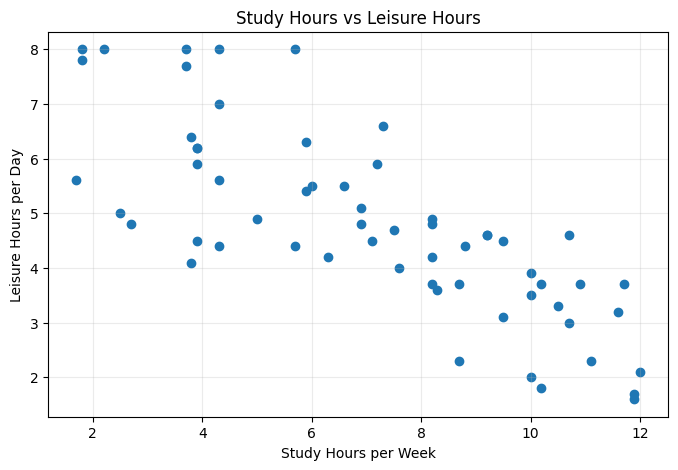

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours_per_week"], df["leisure_hours_per_day"])
plt.xlabel("Study Hours per Week")
plt.ylabel("Leisure Hours per Day")
plt.title("Study Hours vs Leisure Hours")
plt.grid(alpha=0.25)
plt.show()


The first relationship is designed to be positive, while the second is designed to be negative.

The scatter plots and covariance signs should tell a consistent story.


## 8. Covariance Matrix

When a dataset contains several quantitative variables, we can calculate covariance for every pair at once.


In [12]:
numeric_cols = [
    "study_hours_per_week",
    "exam_score",
    "leisure_hours_per_day"
]

cov_matrix = df[numeric_cols].cov()
cov_matrix


,study_hours_per_week,exam_score,leisure_hours_per_day
study_hours_per_week,9.143040,25.016791,-4.021384
exam_score,25.016791,126.064904,-9.963446
leisure_hours_per_day,-4.021384,-9.963446,2.892302


The diagonal contains the covariance of each variable with itself.

But

$$
\operatorname{Cov}(X,X)=\operatorname{Var}(X)
$$

so the diagonal of a covariance matrix contains the **sample variances**.

In [13]:
print("Variance of study hours:")
print(df["study_hours_per_week"].var())

print("\nDiagonal value from covariance matrix:")
print(cov_matrix.loc["study_hours_per_week", "study_hours_per_week"])


Variance of study hours:
9.143039548022598

Diagonal value from covariance matrix:
9.143039548022594


## 9. Covariance with NumPy

NumPy can also calculate a covariance matrix.


In [14]:
np.cov(
    df["study_hours_per_week"],
    df["exam_score"],
    ddof=1
)


array([[  9.14303955,  25.01679096],
       [ 25.01679096, 126.06490395]])

`np.cov()` returns a matrix.

The off-diagonal values represent covariance between the two variables, while the diagonal values represent their variances.


## 10. An Important Limitation: Covariance Depends on Units

The sign of covariance is easy to interpret.

Its **magnitude**, however, is harder to interpret because covariance depends on the units and scales of the original variables.

Let's convert weekly study hours into weekly study minutes.


In [15]:
df["study_minutes_per_week"] = df["study_hours_per_week"] * 60

cov_hours = df["study_hours_per_week"].cov(df["exam_score"])
cov_minutes = df["study_minutes_per_week"].cov(df["exam_score"])

print("Covariance using hours:", cov_hours)
print("Covariance using minutes:", cov_minutes)
print("Ratio:", cov_minutes / cov_hours)


Covariance using hours: 25.016790960451974
Covariance using minutes: 1501.007457627119
Ratio: 60.00000000000002


Changing hours to minutes multiplies the covariance by 60.

The underlying relationship has not changed, but the numerical covariance has changed dramatically.

Therefore:

> **Covariance is useful for identifying direction, but its raw magnitude is not standardized.**

This limitation motivates **correlation**, which we will study in Chapter 17.


## 11. Covariance Does Not Mean Causation

A positive or negative covariance describes a pattern in the observed data.

It does **not** prove that changing one variable causes the other variable to change.

For example, even if study hours and exam scores have positive covariance, other variables may also influence exam performance.

Statistical association and causal explanation are different questions.


## 12. Near-Zero Covariance Does Not Always Mean No Relationship

Covariance focuses on linear co-movement.

A nonlinear relationship can exist even when covariance is small or close to zero.

This is one reason scatter plots remain important: a single numerical statistic cannot reveal every possible pattern.


Covariance: 8.074349270001139e-16


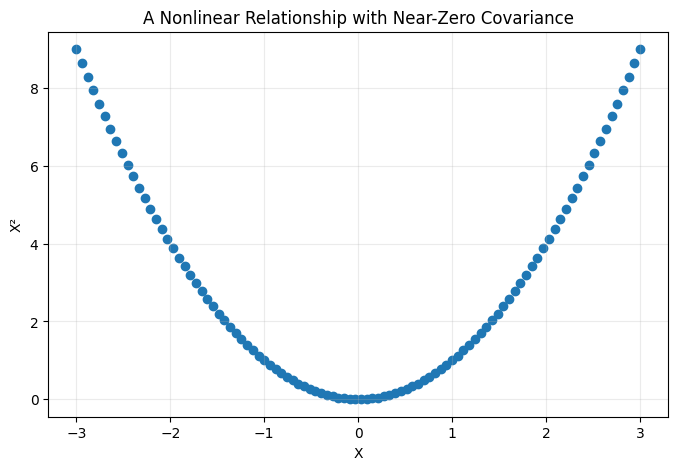

In [16]:
x_curve = np.linspace(-3, 3, 100)
y_curve = x_curve ** 2

print("Covariance:", np.cov(x_curve, y_curve, ddof=1)[0, 1])

plt.figure(figsize=(8, 5))
plt.scatter(x_curve, y_curve)
plt.xlabel("X")
plt.ylabel("X²")
plt.title("A Nonlinear Relationship with Near-Zero Covariance")
plt.grid(alpha=0.25)
plt.show()


## 13. Population Covariance vs Sample Covariance

For a population, covariance can be written as

$$
\operatorname{Cov}(X,Y)
=
\frac{1}{N}
\sum_{i=1}^{N}(x_i-\mu_X)(y_i-\mu_Y)
$$

For a sample, we use

$$
s_{XY}
=
\frac{1}{n-1}
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

In practical data analysis, we often work with samples, so pandas uses the sample covariance convention.

## 14. Exercises

### Exercise 1
Calculate the covariance between `exam_score` and `leisure_hours_per_day`.

- Is it positive or negative?
- What does the sign suggest?

### Exercise 2
Reproduce the covariance between study hours and leisure hours manually using centered deviations.

### Exercise 3
Create a covariance matrix containing all numeric variables except `study_minutes_per_week`.

### Exercise 4
Convert `exam_score` to a different scale by multiplying it by 10.

Calculate the covariance with study hours again.

What happens to the covariance?

### Exercise 5
Explain in your own words why a covariance of `20` cannot automatically be described as "strong."

### Exercise 6
Why should a scatter plot be examined even when covariance is close to zero?


## 15. Summary

In this chapter, we learned that covariance measures how two quantitative variables vary together.

The basic workflow was:

\[
\text{Two Quantitative Variables}
\rightarrow
\text{Scatter Plot}
\rightarrow
\text{Centered Deviations}
\rightarrow
\text{Covariance}
\rightarrow
\text{Interpret the Sign}
\]

Key points:

- Positive covariance indicates same-direction co-movement
- Negative covariance indicates opposite-direction co-movement
- Near-zero covariance indicates little **linear** co-movement
- Covariance can be calculated from products of centered deviations
- The diagonal of a covariance matrix contains variances
- Covariance depends on measurement units
- Covariance does not establish causation
- A near-zero covariance does not rule out nonlinear relationships

### Next Chapter

**Chapter 17 — Correlation Analysis**

Correlation standardizes covariance, making the strength and direction of a linear relationship easier to interpret and compare.
